In [20]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

In [21]:
#Upload and load the dataset
df = pd.read_csv("/content/creditcard.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (284807, 31)


In [22]:
#Look at the dataset
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [23]:
#Check dataset information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [24]:
#Check missing values
print(df.isnull().sum().sum())

0


In [25]:
#Check target distribution
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [26]:
print(df["Class"].value_counts(normalize=True) * 100)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [27]:
#Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (284807, 30)
Target shape: (284807,)


In [28]:
#Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (227845, 30)
Testing data: (56962, 30)


In [29]:
#Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [30]:
#Logistic Regression WITHOUT L2
model_no_l2 = LogisticRegression(
    penalty=None,
    max_iter=1000
)

model_no_l2.fit(X_train_scaled, y_train)

print("Logistic Regression without L2 trained successfully.")

Logistic Regression without L2 trained successfully.


In [31]:
#Get probability predictions
y_prob_no_l2 = model_no_l2.predict_proba(X_test_scaled)[:, 1]

print(y_prob_no_l2[:10])

[4.93513264e-05 2.70425310e-05 1.78856108e-06 8.42268375e-05
 8.05728493e-03 1.85200552e-04 3.60187384e-05 1.25653194e-04
 8.61197339e-04 2.40526902e-05]


In [32]:
#Calculate ROC and AUC without L2
fpr_no_l2, tpr_no_l2, thresholds_no_l2 = roc_curve(
    y_test,
    y_prob_no_l2
)

auc_no_l2 = roc_auc_score(
    y_test,
    y_prob_no_l2
)

print("AUC without L2:", auc_no_l2)

AUC without L2: 0.957588747372894


In [33]:
#Logistic Regression WITH L2
model_l2 = LogisticRegression(
    penalty="l2",
    max_iter=1000
)

model_l2.fit(X_train_scaled, y_train)

print("Logistic Regression with L2 trained successfully.")

Logistic Regression with L2 trained successfully.


In [34]:
#Get probability predictions
y_prob_l2 = model_l2.predict_proba(X_test_scaled)[:, 1]

print(y_prob_l2[:10])

[6.66589547e-05 3.65855419e-05 6.07869420e-06 1.04140855e-04
 7.65924761e-03 2.28829338e-04 5.12814321e-05 1.41758870e-04
 7.59584282e-04 3.49946251e-05]


In [35]:
#Calculate ROC and AUC with L2
fpr_l2, tpr_l2, thresholds_l2 = roc_curve(
    y_test,
    y_prob_l2
)

auc_l2 = roc_auc_score(
    y_test,
    y_prob_l2
)

print("AUC with L2:", auc_l2)

AUC with L2: 0.9605494455801453


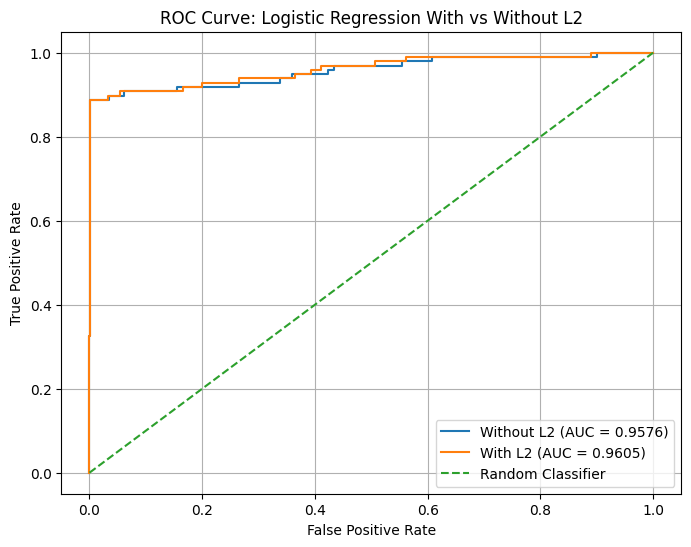

In [36]:
#Plot both ROC curves
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_no_l2,
    tpr_no_l2,
    label=f"Without L2 (AUC = {auc_no_l2:.4f})"
)

plt.plot(
    fpr_l2,
    tpr_l2,
    label=f"With L2 (AUC = {auc_l2:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Logistic Regression With vs Without L2")
plt.legend()
plt.grid()
plt.show()

In [37]:
#AUC comparison
print("\n==============================")
print("FINAL AUC COMPARISON")
print("==============================")

print(f"AUC without L2 : {auc_no_l2:.4f}")
print(f"AUC with L2    : {auc_l2:.4f}")


FINAL AUC COMPARISON
AUC without L2 : 0.9576
AUC with L2    : 0.9605


In [38]:
#Calculate the difference
auc_difference = abs(auc_no_l2 - auc_l2)

print(f"AUC difference : {auc_difference:.6f}")

AUC difference : 0.002961
